In [2]:
pip install catboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


📊 Loading Data & Creating Adaptive Baselines...
   ✅ Created 3 New Adaptive Features.
   Example: Temp 90F in a 70F month -> Anomaly +20 (High Risk)

🧠 Training CatBoost Model...
0:	learn: 0.6753362	total: 46.4ms	remaining: 23.2s
100:	learn: 0.4664556	total: 1.26s	remaining: 4.99s
200:	learn: 0.4333314	total: 2.49s	remaining: 3.7s
300:	learn: 0.3995931	total: 3.69s	remaining: 2.44s
400:	learn: 0.3788916	total: 4.9s	remaining: 1.21s
499:	learn: 0.3639672	total: 6.11s	remaining: 0us

🏆 CATBOOST ADAPTIVE RESULTS
1. ACCURACY:  82.31%
2. RECALL:    84.32%
--------------------------------------------------
              precision    recall  f1-score   support

        Safe       0.84      0.80      0.82      2031
        Fire       0.81      0.84      0.82      1971

    accuracy                           0.82      4002
   macro avg       0.82      0.82      0.82      4002
weighted avg       0.82      0.82      0.82      4002


📝 What matters most? (Feature Importance)
             Feature  

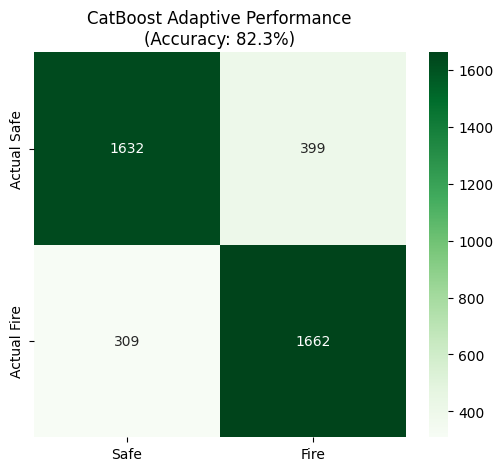

<Figure size 640x480 with 0 Axes>

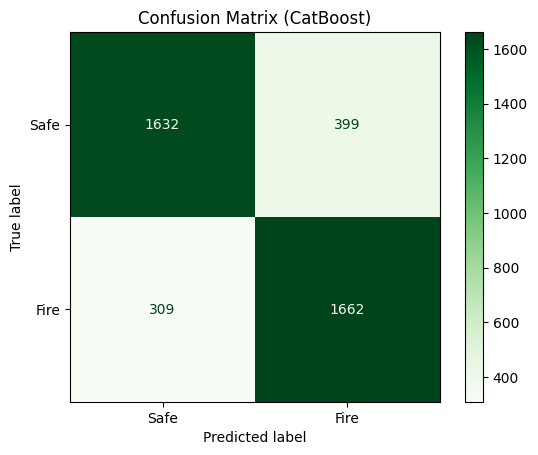

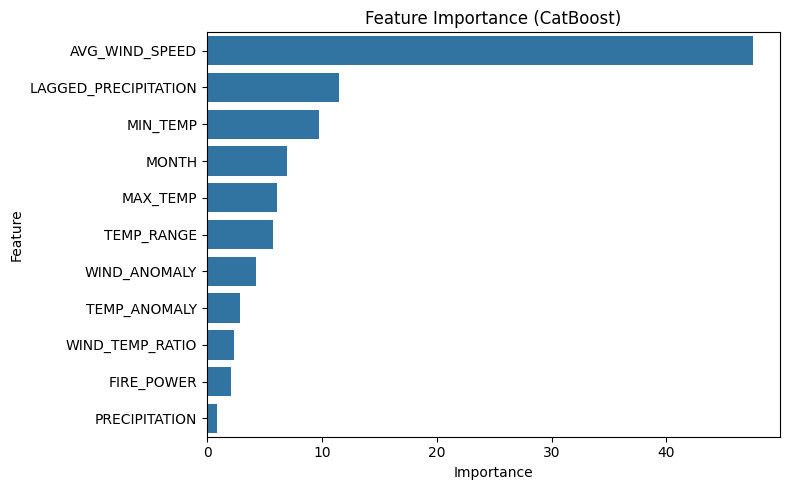

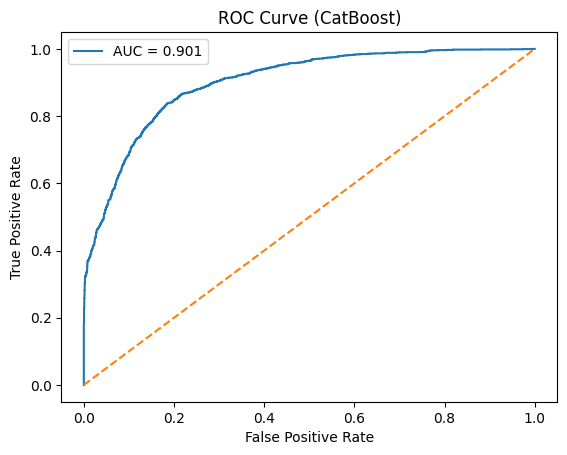

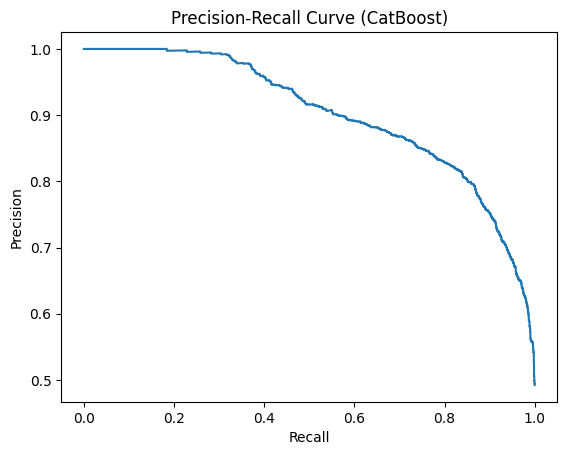

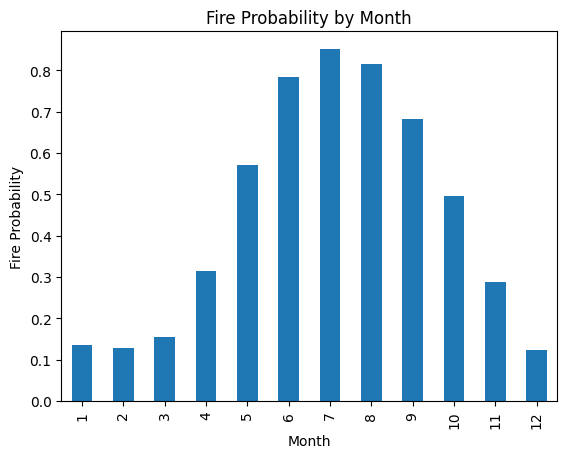


✅ All graphs generated successfully!

✅ Model saved as 'fire_model_catboost.pkl'
✅ Baselines saved as 'monthly_baselines.pkl' (Needed for app.py)


In [7]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, classification_report
# import sys
# sys.path.append("F:/MAJOR")   # folder, not file

# # from fuzzy_logic_module import FuzzyFireSystem

# fuzzy_system = FuzzyFireSystem()
# ==========================================
# ⚙️ CONFIGURATION
# ==========================================
DATASET_PATH = "california_fire_data_balanced.csv"
OUTPUT_MODEL = "fire_model_catboost.pkl"
TARGET = "FIRE_START_DAY"

# Base Sensor Features
FEATURES = [
    'MAX_TEMP', 'MIN_TEMP', 'AVG_WIND_SPEED', 
    'PRECIPITATION', 'LAGGED_PRECIPITATION', 
    'TEMP_RANGE', 'WIND_TEMP_RATIO', 'MONTH'
]

# ==========================================
# 1. LOAD & ENGINEER ADAPTIVE FEATURES
# ==========================================
print("📊 Loading Data & Creating Adaptive Baselines...")
try:
    df = pd.read_csv(DATASET_PATH)
    df = df[FEATURES + [TARGET]].dropna()
except FileNotFoundError:
    print(f"❌ Error: '{DATASET_PATH}' not found.")
    exit()

# --- GUIDE'S SUGGESTION: "Adaptive Baselines" ---
# Instead of raw numbers, we calculate DEVIATION from the norm.

# 1. Calculate Monthly Averages (The Baseline)
monthly_stats = df.groupby('MONTH')[['MAX_TEMP', 'AVG_WIND_SPEED']].transform('mean')

# 2. Create Deviation Features (The Anomaly Signal)
# "How much hotter is today than the average for this month?"
df['TEMP_ANOMALY'] = df['MAX_TEMP'] - monthly_stats['MAX_TEMP']
# "Is the wind unusually strong for this time of year?"
df['WIND_ANOMALY'] = df['AVG_WIND_SPEED'] - monthly_stats['AVG_WIND_SPEED']

# 3. Fire Power Index (Interaction)
df['FIRE_POWER'] = df['MAX_TEMP'] * df['AVG_WIND_SPEED']

# Update Feature List
ALL_FEATURES = FEATURES + ['TEMP_ANOMALY', 'WIND_ANOMALY', 'FIRE_POWER']

print(f"   ✅ Created 3 New Adaptive Features.")
print(f"   Example: Temp 90F in a 70F month -> Anomaly +20 (High Risk)")

X = df[ALL_FEATURES]
y = df[TARGET]

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 2. TRAIN CATBOOST (The "Kaggle Champion")
# ==========================================
print("\n🧠 Training CatBoost Model...")

# CatBoost handles these numeric anomalies better than Random Forest
model = CatBoostClassifier(
    iterations=500,          # Train 500 correction trees
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,           # Regularization to prevent overfitting
    loss_function='Logloss',
    verbose=100              # Print progress every 100 steps
)

model.fit(X_train, y_train)

# ==========================================
# 3. EVALUATION
# ==========================================
print("\n🏆 CATBOOST ADAPTIVE RESULTS")
print("="*50)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"1. ACCURACY:  {acc*100:.2f}%")
print(f"2. RECALL:    {rec*100:.2f}%")
print("-" * 50)
print(classification_report(y_test, y_pred, target_names=["Safe", "Fire"]))

# Feature Importance
print("\n📝 What matters most? (Feature Importance)")
importances = pd.DataFrame({'Feature': ALL_FEATURES, 'Importance': model.get_feature_importance()})
importances = importances.sort_values(by='Importance', ascending=False)
print(importances.to_string(index=False))

# Visual Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Safe', 'Fire'],
            yticklabels=['Actual Safe', 'Actual Fire'])
plt.title(f'CatBoost Adaptive Performance\n(Accuracy: {acc*100:.1f}%)')
plt.show()

# ==========================================
# 📊 ADVANCED VISUALIZATION BLOCK (THESIS)
# ==========================================

from sklearn.metrics import roc_curve, auc, precision_recall_curve, ConfusionMatrixDisplay

# --- 1. CONFUSION MATRIX (CLEAN VERSION) ---
plt.figure()
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Safe", "Fire"],
    cmap='Greens'
)
plt.title("Confusion Matrix (CatBoost)")
plt.show()


# --- 2. FEATURE IMPORTANCE (GRAPH) ---
plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=importances)
plt.title("Feature Importance (CatBoost)")
plt.tight_layout()
plt.show()


# --- 3. ROC CURVE ---
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (CatBoost)")
plt.legend()
plt.show()


# --- 4. PRECISION-RECALL CURVE ---
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (CatBoost)")
plt.show()

# --- 7. MONTHLY FIRE TREND ---
plt.figure()
df.groupby('MONTH')[TARGET].mean().plot(kind='bar')
plt.title("Fire Probability by Month")
plt.xlabel("Month")
plt.ylabel("Fire Probability")
plt.show()


print("\n✅ All graphs generated successfully!")
# ==========================================
# 4. SAVE MODEL & BASELINES
# ==========================================
joblib.dump(model, OUTPUT_MODEL)

# CRITICAL: We need to save the monthly averages so app.py can calculate anomalies!
monthly_baselines = df.groupby('MONTH')[['MAX_TEMP', 'AVG_WIND_SPEED']].mean().to_dict()
joblib.dump(monthly_baselines, "monthly_baselines.pkl")

print(f"\n✅ Model saved as '{OUTPUT_MODEL}'")
print(f"✅ Baselines saved as 'monthly_baselines.pkl' (Needed for app.py)")